# Realistic Human Face Generation using GAN (DCGAN)

**Goal:** train a Generative Adversarial Network that generates realistic
synthetic human face images from random noise vectors.

This notebook is built to run on **Kaggle Notebooks** (GPU: T4/P100) or
**Google Colab**. It covers:

1. Downloading and preprocessing a real face dataset (CelebA).
2. Building a Generator and a Discriminator (DCGAN-style, 128x128 output).
3. Adversarial training with loss tracking and periodic sample saving.
4. Visual comparison of generated faces over training epochs.
5. A themed **Streamlit** web app (tunneled with **ngrok**) to try the
   trained Generator interactively.

> Run the cells top to bottom. If you are on Kaggle, turn on the GPU
> accelerator and turn on Internet access in the notebook settings so the
> Kaggle dataset download and `pip install` cells work.


## 1. Setup & Installs

In [1]:
# Core + extra packages needed across the notebook
!pip install -q torch torchvision torchmetrics kagglehub streamlit pyngrok --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5

In [2]:
import os, time, glob, random, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


Using device: cuda
Tesla T4


## 2. Dataset — CelebA (Kaggle)

We use **CelebA** (`jessicali9530/celeba-dataset`), the standard benchmark
for face-generation GANs: ~202,599 aligned & cropped celebrity face images.
It downloads directly through `kagglehub` (works out of the box on Kaggle
Notebooks; on Colab you'll need to upload your `kaggle.json` API token
first).


In [3]:
import kagglehub

# On Kaggle Notebooks this uses the built-in credentials automatically.
# On Colab: upload kaggle.json first, e.g.
#   from google.colab import files; files.upload()
#   !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset downloaded to:", dataset_path)

# Locate the folder that actually contains the .jpg images
img_dir_candidates = glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True)
print("Found", len(img_dir_candidates), "images")
IMG_ROOT = os.path.dirname(img_dir_candidates[0]) if img_dir_candidates else dataset_path
print("Image root folder:", IMG_ROOT)


Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset downloaded to: /kaggle/input/celeba-dataset
Found 202599 images
Image root folder: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba


In [4]:
# OPTIONAL: cap the number of training images for faster experimentation.
# Set to None to use the full dataset (~202k images, best final quality but slower).
MAX_IMAGES = 60000

all_image_paths = sorted(glob.glob(os.path.join(IMG_ROOT, "*.jpg")))
if MAX_IMAGES is not None:
    all_image_paths = all_image_paths[:MAX_IMAGES]
print("Training on", len(all_image_paths), "images")


Training on 60000 images


## 3. Preprocessing

CelebA images are already roughly face-centered, so preprocessing is:
**center-crop** (to remove background / keep the face square) → **resize**
to the training resolution → **normalize** to `[-1, 1]` (matches the
Generator's final `Tanh` activation).


In [5]:
IMAGE_SIZE = 128   # generator/discriminator output resolution
CROP_SIZE  = 178    # CelebA faces are well framed inside a 178x178 center crop

transform = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # -> [-1, 1]
])

class FaceDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

dataset = FaceDataset(all_image_paths, transform)

BATCH_SIZE = 128
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)
print("Batches per epoch:", len(dataloader))


Batches per epoch: 468


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:431: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:437: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


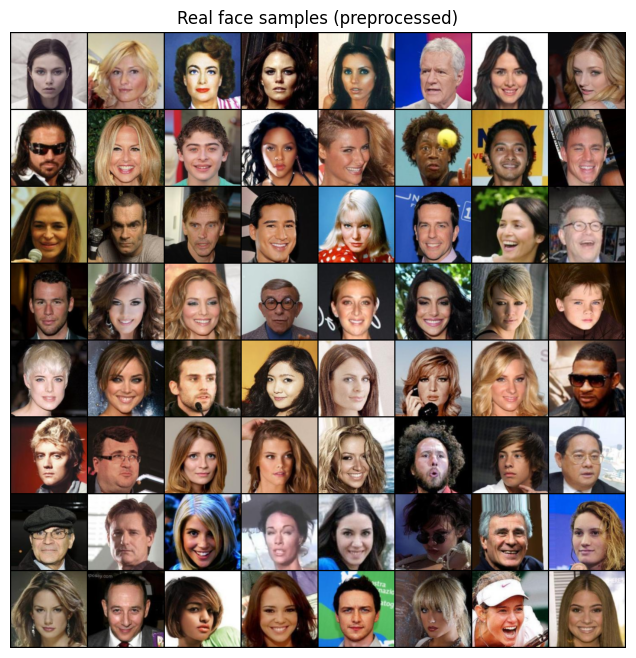

In [6]:
# Sanity check: visualize a batch of real, preprocessed faces
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real face samples (preprocessed)")
grid = vutils.make_grid(real_batch[:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
plt.show()


## 4. Models

**Generator:** maps a latent vector `z` (shape `nz`) through a stack of
`ConvTranspose2d` blocks up to a `128x128x3` RGB image (`Tanh` output).

**Discriminator:** mirrors the Generator with strided `Conv2d` blocks down
to a single real/fake logit. `spectral_norm` is applied to every conv layer
for training stability (a well-known trick that prevents the discriminator
from overpowering the generator early in training).

These are intentionally **not tiny** — deep enough (6 conv blocks each,
channel widths up to 1024) to produce good quality 128x128 faces, while
still training in reasonable time on a single Kaggle/Colab GPU.


In [7]:
NZ = 128      # latent vector size
NGF = 64      # base generator feature maps
NDF = 64      # base discriminator feature maps
NC = 3        # RGB channels

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    """z (NZ,1,1) -> 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64 -> 128x128x3"""
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16), nn.ReLU(True),                 # 4x4

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),                  # 8x8

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),                  # 16x16

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),                  # 32x32

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),                      # 64x64

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),                                               # 128x128
        )

    def forward(self, z):
        return self.main(z)


class Discriminator(nn.Module):
    """128x128x3 -> ... -> 1 logit (spectral-normalized convs)"""
    def __init__(self, ndf=NDF, nc=NC):
        super().__init__()
        sn = nn.utils.spectral_norm
        self.main = nn.Sequential(
            sn(nn.Conv2d(nc, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),                         # 64x64

            sn(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),                         # 32x32

            sn(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),                         # 16x16

            sn(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),                         # 8x8

            sn(nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),                         # 4x4

            sn(nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False)),         # 1x1 logit
        )

    def forward(self, x):
        return self.main(x).view(-1)


netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

n_params_g = sum(p.numel() for p in netG.parameters())
n_params_d = sum(p.numel() for p in netD.parameters())
print(f"Generator params:     {n_params_g:,}")
print(f"Discriminator params: {n_params_d:,}")
print(netG)
print(netD)


Generator params:     13,245,312
Discriminator params: 11,160,576
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    

## 5. Loss, Optimizers & Training Config

Standard DCGAN adversarial setup:
- `BCEWithLogitsLoss` (matches the raw logits returned by the Discriminator).
- One-sided **label smoothing** on real labels (0.9 instead of 1.0) — a
  simple, well-known trick that stabilizes GAN training.
- Adam optimizers with `betas=(0.5, 0.999)`, the standard DCGAN setting.


In [8]:
LR = 2e-4
BETA1 = 0.5
EPOCHS = 40                 # increase for better final quality
SAMPLE_EVERY_N_STEPS = 200  # how often to log losses
CKPT_DIR = "checkpoints"
SAMPLES_DIR = "samples"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

criterion = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

REAL_LABEL, FAKE_LABEL = 0.9, 0.0  # label smoothing on real
fixed_noise = torch.randn(64, NZ, 1, 1, device=device)  # for consistent progress snapshots


## 6. Training Loop

For every batch:
1. **Train D** on a real batch, then on a detached fake batch from `G`.
2. **Train G** by trying to fool `D` on a fresh fake batch.
3. Log `loss_D` / `loss_G` and, once per epoch, save a grid of generated
   samples from the fixed noise vector so progress is directly comparable
   across epochs.


In [9]:
G_losses, D_losses = [], []
epoch_sample_paths = []

start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    for i, real_imgs in enumerate(dataloader):
        real_imgs = real_imgs.to(device, non_blocking=True)
        b_size = real_imgs.size(0)

        # ---------------- Train Discriminator ----------------
        netD.zero_grad()
        label_real = torch.full((b_size,), REAL_LABEL, device=device)
        out_real = netD(real_imgs)
        loss_d_real = criterion(out_real, label_real)

        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        label_fake = torch.full((b_size,), FAKE_LABEL, device=device)
        out_fake = netD(fake_imgs.detach())
        loss_d_fake = criterion(out_fake, label_fake)

        loss_D = loss_d_real + loss_d_fake
        loss_D.backward()
        optimizerD.step()

        # ------------------ Train Generator -------------------
        netG.zero_grad()
        label_gen = torch.full((b_size,), 1.0, device=device)  # G wants D to say "real"
        out_gen = netD(fake_imgs)
        loss_G = criterion(out_gen, label_gen)
        loss_G.backward()
        optimizerG.step()

        if i % SAMPLE_EVERY_N_STEPS == 0:
            G_losses.append(loss_G.item())
            D_losses.append(loss_D.item())
            elapsed = time.time() - start_time
            print(f"[Epoch {epoch}/{EPOCHS}][Batch {i}/{len(dataloader)}] "
                  f"loss_D: {loss_D.item():.4f}  loss_G: {loss_G.item():.4f}  "
                  f"elapsed: {elapsed/60:.1f} min")

    # ---- End of epoch: save a snapshot grid from the FIXED noise ----
    netG.eval()
    with torch.no_grad():
        fake_fixed = netG(fixed_noise).detach().cpu()
    netG.train()

    grid = vutils.make_grid(fake_fixed, padding=2, normalize=True)
    sample_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch:03d}.png")
    vutils.save_image(grid, sample_path)
    epoch_sample_paths.append(sample_path)

    # ---- Periodic checkpoint ----
    if epoch % 5 == 0 or epoch == EPOCHS:
        torch.save(netG.state_dict(), os.path.join(CKPT_DIR, f"generator_epoch{epoch:03d}.pth"))
        torch.save(netD.state_dict(), os.path.join(CKPT_DIR, f"discriminator_epoch{epoch:03d}.pth"))

print("Training finished in", round((time.time() - start_time) / 60, 1), "minutes")


[Epoch 1/40][Batch 0/468] loss_D: 1.3522  loss_G: 0.5833  elapsed: 0.1 min
[Epoch 1/40][Batch 200/468] loss_D: 1.1080  loss_G: 0.6924  elapsed: 2.6 min
[Epoch 1/40][Batch 400/468] loss_D: 1.2632  loss_G: 0.6689  elapsed: 5.3 min
[Epoch 2/40][Batch 0/468] loss_D: 1.2031  loss_G: 0.7515  elapsed: 6.2 min
[Epoch 2/40][Batch 200/468] loss_D: 1.2012  loss_G: 0.7221  elapsed: 8.8 min
[Epoch 2/40][Batch 400/468] loss_D: 1.1708  loss_G: 0.7520  elapsed: 11.5 min
[Epoch 3/40][Batch 0/468] loss_D: 1.2248  loss_G: 0.7188  elapsed: 12.4 min
[Epoch 3/40][Batch 200/468] loss_D: 1.1591  loss_G: 0.7934  elapsed: 15.1 min
[Epoch 3/40][Batch 400/468] loss_D: 1.1389  loss_G: 0.7622  elapsed: 17.7 min
[Epoch 4/40][Batch 0/468] loss_D: 1.1443  loss_G: 0.7663  elapsed: 18.7 min
[Epoch 4/40][Batch 200/468] loss_D: 1.1709  loss_G: 0.7705  elapsed: 21.3 min
[Epoch 4/40][Batch 400/468] loss_D: 1.1704  loss_G: 0.7185  elapsed: 24.0 min
[Epoch 5/40][Batch 0/468] loss_D: 1.0627  loss_G: 0.8416  elapsed: 24.9 min
[

## 7. Loss Curves

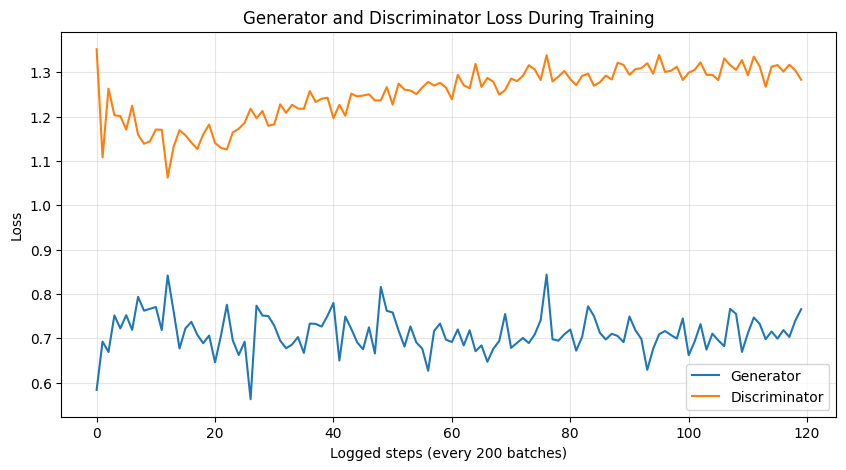

In [10]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel(f"Logged steps (every {SAMPLE_EVERY_N_STEPS} batches)")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 8. Quality Over Time — Epoch Progression

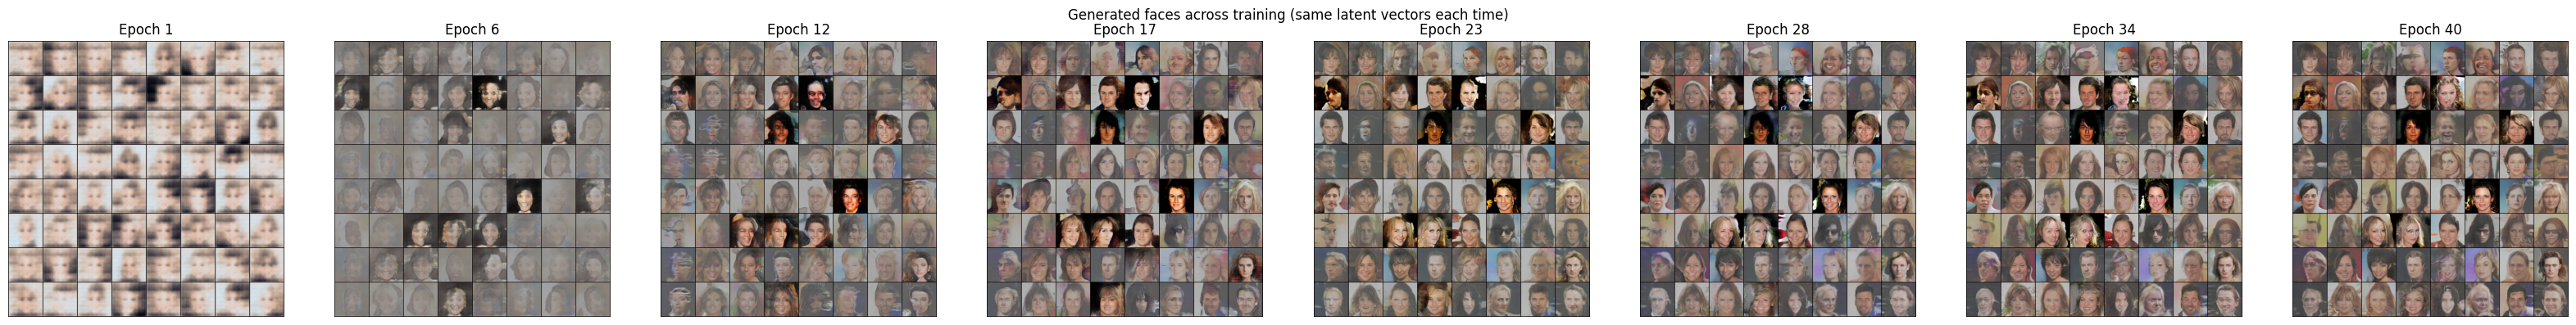

In [11]:
# Show how generated faces (from the SAME fixed noise) evolve across training
n_show = min(8, len(epoch_sample_paths))
show_idxs = np.linspace(0, len(epoch_sample_paths) - 1, n_show).astype(int)

fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]
for ax, idx in zip(axes, show_idxs):
    img = Image.open(epoch_sample_paths[idx])
    ax.imshow(img)
    ax.set_title(f"Epoch {idx + 1}")
    ax.axis("off")
plt.suptitle("Generated faces across training (same latent vectors each time)")
plt.tight_layout()
plt.show()


## 9. Final Generated Faces

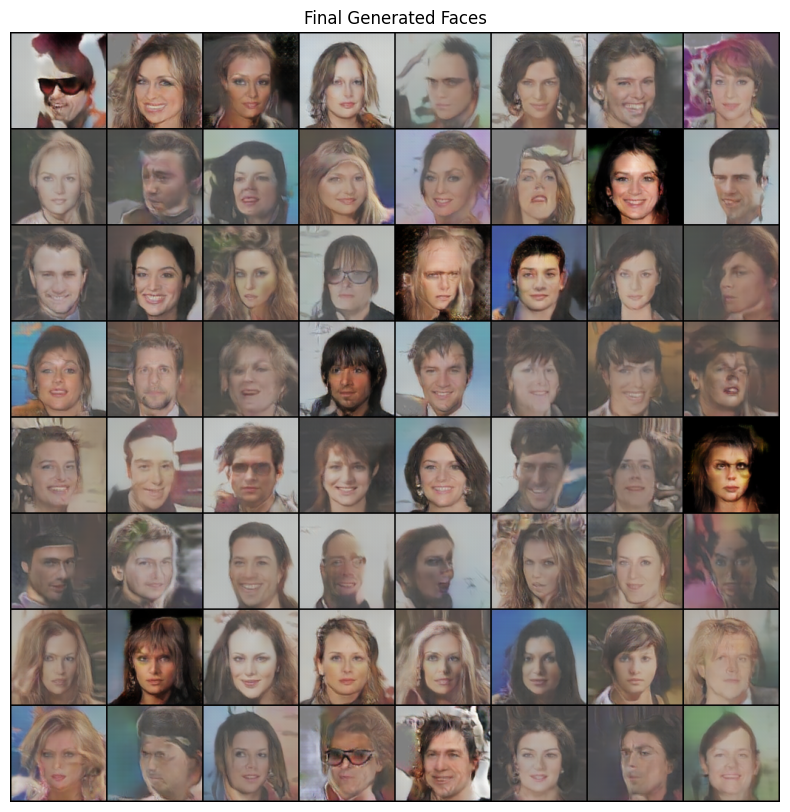

In [12]:
netG.eval()
with torch.no_grad():
    final_noise = torch.randn(64, NZ, 1, 1, device=device)
    final_fakes = netG(final_noise).detach().cpu()

plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Final Generated Faces")
grid = vutils.make_grid(final_fakes, padding=2, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()


In [13]:
# Save the final generator for the Streamlit app
FINAL_GEN_PATH = "generator_final.pth"
torch.save(netG.state_dict(), FINAL_GEN_PATH)
print("Saved:", FINAL_GEN_PATH)


Saved: generator_final.pth


## 10. Streamlit Demo App (via ngrok)

This writes a standalone `app.py` Streamlit app that loads
`generator_final.pth` and lets you generate new faces interactively from a
browser, then tunnels it publicly with `pyngrok` (works from inside a
Kaggle/Colab notebook, no local machine needed).

**You need a free ngrok account & authtoken:** https://dashboard.ngrok.com/get-started/your-authtoken
Paste it into `NGROK_AUTH_TOKEN` below before running.


In [14]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import torchvision.utils as vutils
import numpy as np
from PIL import Image
import io

# ----------------------------- Model definition (must match training) -----------------------------
NZ, NGF, NC = 128, 64, 3

class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.main(z)

# ----------------------------------------- Page setup -----------------------------------------
st.set_page_config(page_title="AI Face Generator", page_icon="\U0001F9EC", layout="wide")

CUSTOM_CSS = """
<style>
:root {
    --accent1: #7b2ff7;
    --accent2: #00d4ff;
    --bg: #0f0c1d;
    --card: #1a1533;
}
.stApp {
    background: radial-gradient(circle at top left, #1a1533 0%, #0f0c1d 60%);
    color: #eae6ff;
}
h1, h2, h3 { color: #f2eeff !important; }
.hero {
    padding: 28px 32px;
    border-radius: 18px;
    background: linear-gradient(120deg, rgba(123,47,247,0.25), rgba(0,212,255,0.15));
    border: 1px solid rgba(255,255,255,0.08);
    margin-bottom: 24px;
}
.hero h1 { font-size: 2.1rem; margin-bottom: 6px; }
.hero p { color: #c9c3ea; font-size: 1.02rem; }
div.stButton > button {
    background: linear-gradient(120deg, var(--accent1), var(--accent2));
    color: white;
    border: none;
    border-radius: 10px;
    padding: 0.6em 1.6em;
    font-weight: 600;
    letter-spacing: 0.3px;
}
div.stButton > button:hover {
    filter: brightness(1.1);
    color: white;
}
section[data-testid="stSidebar"] {
    background: #150f28;
    border-right: 1px solid rgba(255,255,255,0.06);
}
.stSlider label, .stNumberInput label { color: #c9c3ea !important; }
.face-card {
    background: var(--card);
    border-radius: 14px;
    padding: 10px;
    border: 1px solid rgba(255,255,255,0.06);
}
</style>
"""
st.markdown(CUSTOM_CSS, unsafe_allow_html=True)

st.markdown(
    """
    <div class="hero">
        <h1>\U0001F9EC AI Face Generator</h1>
        <p>DCGAN trained on CelebA \u2014 generate brand-new synthetic human faces from random noise.</p>
    </div>
    """,
    unsafe_allow_html=True,
)

# ----------------------------------------- Model loading -----------------------------------------
@st.cache_resource
def load_generator(path="generator_final.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Generator().to(device)
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model, device

try:
    netG, device = load_generator()
    model_ready = True
except Exception as e:
    model_ready = False
    load_error = str(e)

# ----------------------------------------- Sidebar controls -----------------------------------------
with st.sidebar:
    st.header("Controls")
    n_faces = st.slider("Number of faces", min_value=1, max_value=64, value=16, step=1)
    seed = st.number_input("Random seed (-1 = random)", value=-1, step=1)
    generate_clicked = st.button("\u2728 Generate Faces", use_container_width=True)

if not model_ready:
    st.error(
        "Could not load `generator_final.pth`. Make sure this file is in the same "
        "folder as app.py (it is produced by the training notebook, Section 9)."
    )
    st.caption(f"Details: {load_error}")
else:
    if "faces" not in st.session_state:
        st.session_state.faces = None

    if generate_clicked:
        if seed is not None and seed >= 0:
            torch.manual_seed(int(seed))
        with st.spinner("Generating faces..."):
            with torch.no_grad():
                noise = torch.randn(n_faces, NZ, 1, 1, device=device)
                fakes = netG(noise).cpu()
                fakes = (fakes + 1) / 2.0  # [-1,1] -> [0,1]
        st.session_state.faces = fakes

    if st.session_state.faces is not None:
        fakes = st.session_state.faces
        cols = st.columns(4)
        for idx in range(fakes.shape[0]):
            img = (fakes[idx].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            pil_img = Image.fromarray(img)
            with cols[idx % 4]:
                st.markdown('<div class="face-card">', unsafe_allow_html=True)
                st.image(pil_img, use_container_width=True)
                buf = io.BytesIO()
                pil_img.save(buf, format="PNG")
                st.download_button(
                    "Download", buf.getvalue(), file_name=f"face_{idx}.png",
                    mime="image/png", key=f"dl_{idx}", use_container_width=True,
                )
                st.markdown("</div>", unsafe_allow_html=True)
    else:
        st.info("Set your options in the sidebar and click **Generate Faces** to begin.")


Writing app.py


In [18]:
from pyngrok import ngrok
import subprocess, time

NGROK_AUTH_TOKEN = "3GxwNOupIKCZSt2sqwvURMK7YHj_hoA4nxa6bSJhT1g67mjw"

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

!pkill -f "streamlit run" || true
time.sleep(2)

streamlit_proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
)

time.sleep(6)

public_url = ngrok.connect(8501)
print(public_url)

^C
NgrokTunnel: "https://e6d7-34-21-189-223.ngrok-free.app" -> "http://localhost:8501"


In [19]:
from google.colab import files

!zip -r samples.zip samples
files.download("samples.zip")

  adding: samples/ (stored 0%)
  adding: samples/epoch_040.png (deflated 0%)
  adding: samples/epoch_016.png (deflated 0%)
  adding: samples/epoch_022.png (deflated 0%)
  adding: samples/epoch_009.png (deflated 0%)
  adding: samples/epoch_027.png (deflated 0%)
  adding: samples/epoch_020.png (deflated 0%)
  adding: samples/epoch_038.png (deflated 0%)
  adding: samples/epoch_023.png (deflated 0%)
  adding: samples/epoch_021.png (deflated 0%)
  adding: samples/epoch_025.png (deflated 0%)
  adding: samples/epoch_039.png (deflated 0%)
  adding: samples/epoch_003.png (deflated 0%)
  adding: samples/epoch_007.png (deflated 0%)
  adding: samples/epoch_011.png (deflated 0%)
  adding: samples/epoch_005.png (deflated 0%)
  adding: samples/epoch_012.png (deflated 0%)
  adding: samples/epoch_001.png (deflated 0%)
  adding: samples/epoch_035.png (deflated 0%)
  adding: samples/epoch_034.png (deflated 0%)
  adding: samples/epoch_018.png (deflated 0%)
  adding: samples/epoch_010.png (deflated 0%)
  a

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>